<a href="https://colab.research.google.com/github/harshdeep789-crypto/machine-learning-project/blob/main/Copy_of_Exam_Result_Prediction_(Machine_Learning).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_curve, auc

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
#2. Load the dataset
df=pd.read_csv('/content/exam_result_100 (2).csv')
df.head()

,internal_test_1,internal_test_2,assignment_score,attendance_percentage,study_hours,late_submissions,previous_result,final_result
0,18,20,19,90,12,0,Pass,Pass
1,10,12,13,65,5,3,Fail,Fail
2,22,24,23,95,14,0,Pass,Pass
3,15,17,16,75,8,1,Pass,Pass
4,8,9,10,55,4,4,Fail,Fail


In [ ]:
#3. EDA (exploratory Data Analysis)
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   internal_test_1        200 non-null    int64 
 1   internal_test_2        200 non-null    int64 
 2   assignment_score       200 non-null    int64 
 3   attendance_percentage  200 non-null    int64 
 4   study_hours            200 non-null    int64 
 5   late_submissions       200 non-null    int64 
 6   previous_result        200 non-null    object
 7   final_result           200 non-null    object
dtypes: int64(6), object(2)
memory usage: 12.6+ KB
None
       internal_test_1  internal_test_2  assignment_score  \
count       200.000000       200.000000        200.000000   
mean         15.200000        16.280000         14.840000   
std           6.069944         6.535685          5.606385   
min           5.000000         5.000000          6.000000   
25%          10.000000   

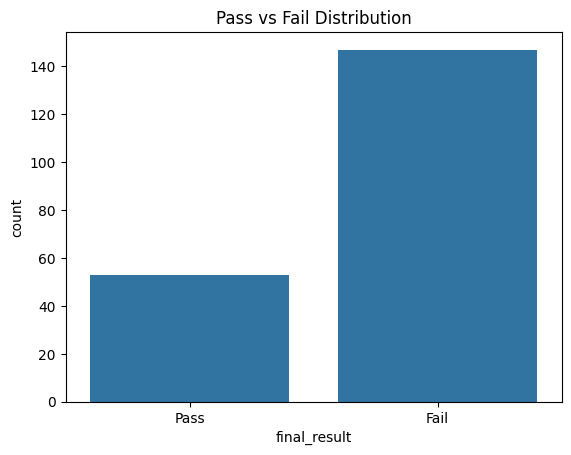

In [ ]:
#4. Graph 1: Pass vs Fail
sns.countplot(x='final_result',data=df)
plt.title("Pass vs Fail Distribution")
plt.show()

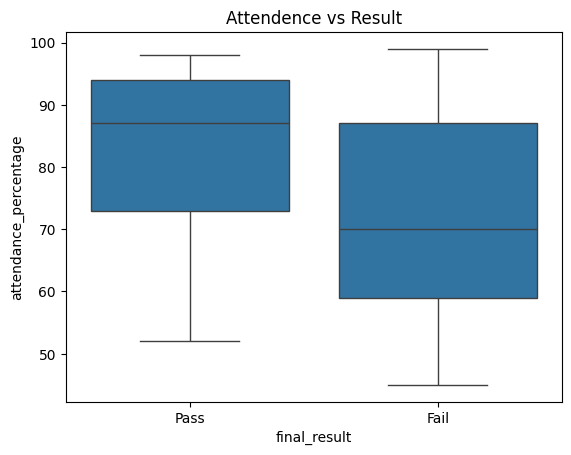

In [ ]:
#5. Graph 2: Attendance vs Result
sns.boxplot(x='final_result',y='attendance_percentage',data=df)
plt.title("Attendence vs Result")
plt.show()

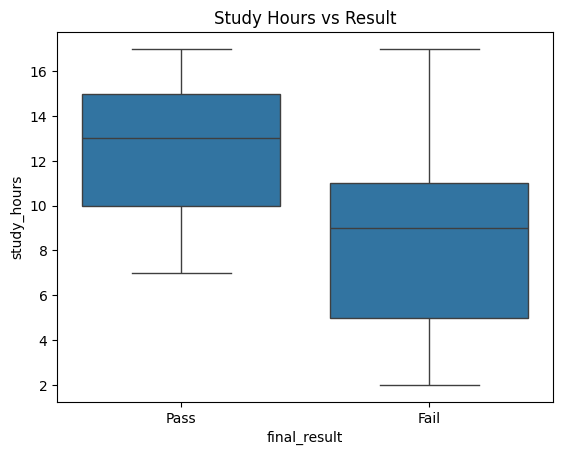

In [ ]:
#6. Graph 3: Study hours vs Result
sns.boxplot(x='final_result' ,y='study_hours',data=df)
plt.title("Study Hours vs Result")
plt.show()

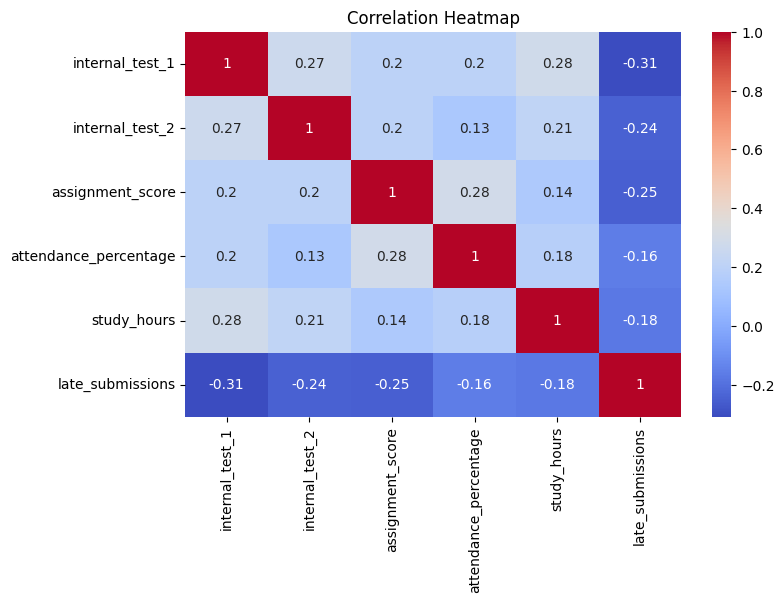

In [ ]:
#7. Graph 7: Correlation Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
#8 Data Preprocessing
le=LabelEncoder()
df['previous_result'] =le.fit_transform(df['previous_result'])
df['final_result']=le.fit_transform(df['final_result'])

In [ ]:
#9. Feature Selection
X=df.drop('final_result',axis=1)
y=df['final_result']

In [ ]:
#10. Train Test Split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
#11. Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#12. Train Multiple models
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}
results = {}
print("\n Model Performance:\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"  {name}: {accuracy:.2f}")


 Model Performance:

  Logistic Regression: 0.90
  Decision Tree: 0.90
  Random Forest: 0.90


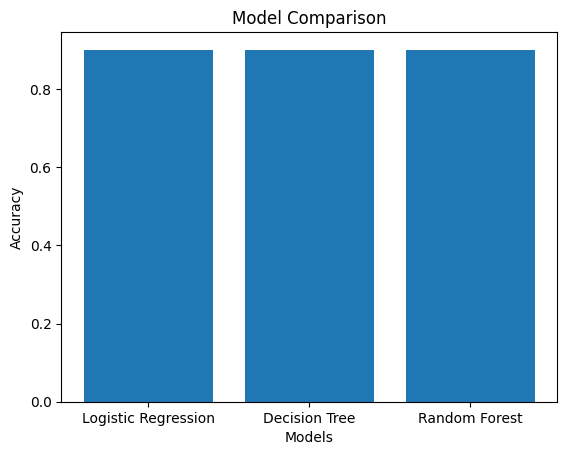

In [ ]:
#13. Model Comparison Graph
plt.figure()
plt.bar(results.keys(), results.values())
plt.title('Model Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.show()

In [ ]:
#14. Hyperparameter Tuning (Important)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
}
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)
best_model = grid.best_estimator_


Best Parameters: {'max_depth': 10, 'n_estimators': 200}


In [ ]:
#15. Cross Validation
cv_scores = cross_val_score(best_model, X, y, cv=5)
print("\n Cross-Validation Scores:", cv_scores)
print("Average CV Score:", np.mean(cv_scores))


 Cross-Validation Scores: [0.975 1.    0.95  0.825 0.85 ]
Average CV Score: 0.9199999999999999


In [ ]:
#16. Final Evaluation
y_pred = best_model.predict(X_test)
print("\n Final Accuracy:", accuracy_score(y_test, y_pred))
print("\n Classification Report:\n")
print(classification_report(y_test, y_pred))


 Final Accuracy: 0.9

 Classification Report:

              precision    recall  f1-score   support

           0       0.89      1.00      0.94        31
           1       1.00      0.56      0.71         9

    accuracy                           0.90        40
   macro avg       0.94      0.78      0.83        40
weighted avg       0.91      0.90      0.89        40



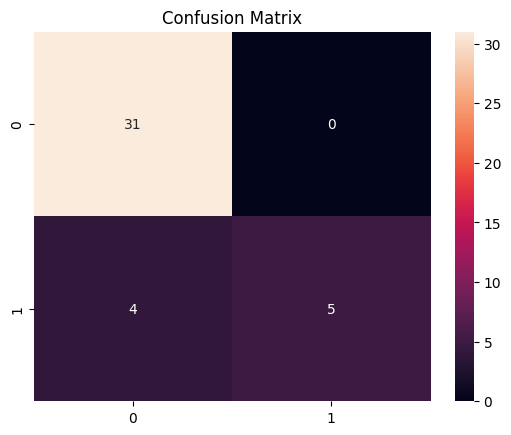

In [ ]:
#17. Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

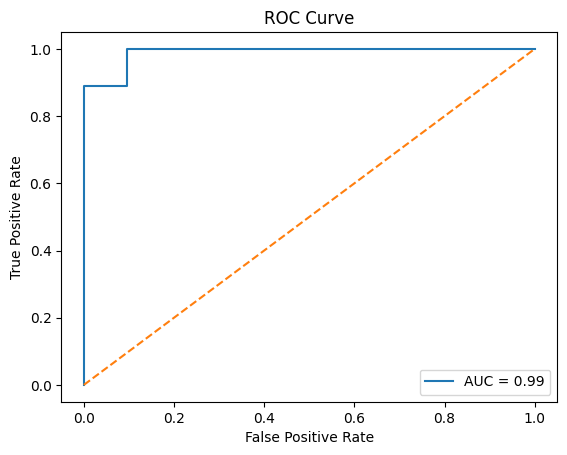

In [ ]:
#18.ROC Curve (High Svoring)
y_prob = best_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

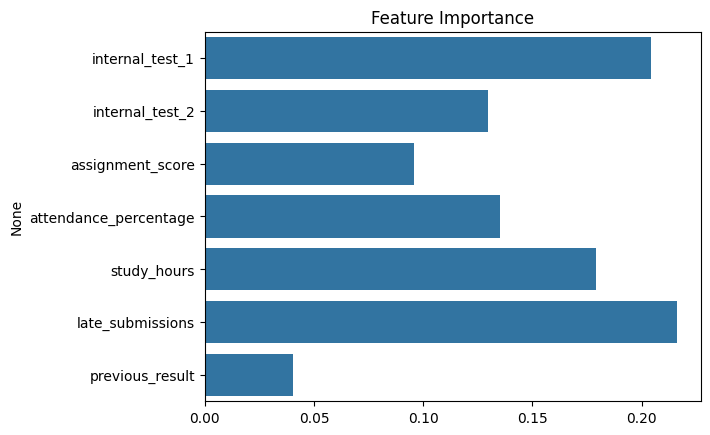

In [ ]:
#19. Feature Importance
importance = best_model.feature_importances_
features = X.columns

plt.figure()
sns.barplot(x=importance, y=features)
plt.title("Feature Importance")
plt.show()


In [ ]:
#20. Prediction System
def predict_student(data):
    data_scaled = scaler.transform([data])
    result = best_model.predict(data_scaled)
    return "Pass ✅" if result[0] == 1 else "Fail"




In [ ]:
#End of Final PRoject
print(" Project Completed Successful")

 Project Completed Successful
